# Day 8 - Model Evaluation

**AI & Machine Learning Internship**

**Author:** Neethu Suresh

## Topics Covered

- Linear Regression
- Model Evaluation
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score
- Actual vs Predicted Visualization

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
df = pd.read_csv("student_scores.csv")

df

,Name,Hours_Studied,Attendance,Previous_Score,Final_Score
0,Anu,2,80.0,65.0,68
1,Rahul,5,92.0,78.0,84
2,Sneha,4,88.0,75.0,80
3,Arjun,6,95.0,82.0,90
4,Meera,3,NaN,70.0,74
5,Akhil,7,90.0,88.0,94
6,Diya,5,85.0,NaN,82
7,Rohan,8,98.0,91.0,96
8,Aisha,2,76.0,60.0,65
9,Vivek,4,89.0,77.0,81


In [14]:
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())
df["Previous_Score"] = df["Previous_Score"].fillna(df["Previous_Score"].mean())

In [15]:
X = df[["Hours_Studied"]]
y = df["Final_Score"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[4.71]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours_Studied']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,60.14
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [18]:
y_pred = model.predict(X_test)

print("Actual Scores")
print(y_test.values)

print()

print("Predicted Scores")
print(y_pred)

Actual Scores
[65 84]

Predicted Scores
[69.57142857 83.71428571]


In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae:.2f}")
print(f"Mean Squared Error  : {mse:.2f}")
print(f"R² Score            : {r2:.2f}")

Mean Absolute Error : 2.43
Mean Squared Error  : 10.49
R² Score            : 0.88


In [20]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,65,69.571429
1,84,83.714286


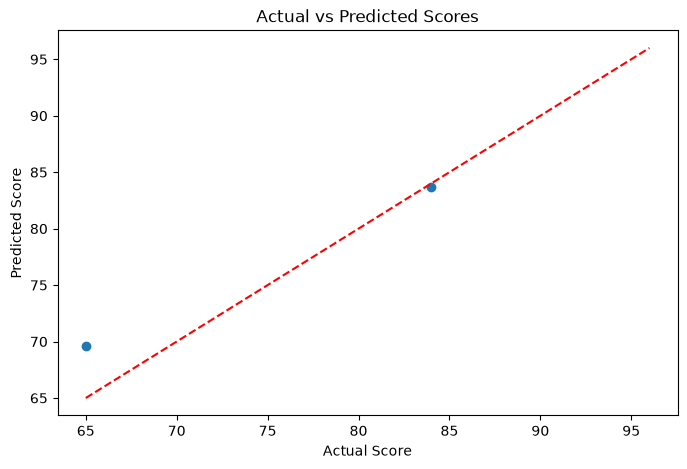

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")

plt.show()

## Conclusion

Model evaluation helps us understand how accurately a machine learning model makes predictions. Metrics such as MAE, MSE, and R² Score are commonly used to measure regression model performance.